# NeuralQ S2SR — Meteo × Health (Open-Meteo ERA5 + 1 m series)

Why the crops did what they did: daily ERA5 meteorology (free, no key) joined to the real 1 m index/health series at Sidi Bouzid fields (9.56E 35.06N).

**Pipeline:**
1. Fetch daily Tmax/Tmin/Tmean, rain, FAO ET0, soil moisture 0–7/7–28 cm (Jan→Jun 2024) + 2015–2023 climatology baseline.
2. Derive GDD (base 10, cap 30), cumulative P−ET0 water balance, heat-stress days (Tmax>35), dry spells, antecedent precipitation index.
3. Overlay with batch NDVI/health series: rain/soil-moisture vs green-down, heat vs MTCI collapse, per-crop × meteo table, irrigation flags.
4. Save `meteo_daily.csv`, `meteo_summary.csv`, figures; append a meteo section to the batch report.

**Resolution honesty:** ERA5 ≈ 9 km — meteo explains the *batch*, never a parcel. Parcel-level claims use only the 1 m indices; meteo provides the weather narrative.

## 0. Setup (inline figures render inside cells)

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT / 'scripts' / 'run_location.py').exists():
    ROOT = Path.cwd().parent
if not (ROOT / 'scripts' / 'run_location.py').exists():
    ROOT = Path('/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core')
print('ROOT', ROOT)
# inline backend: every figure renders INSIDE its cell output, no external viewer needed
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
print('pandas', pd.__version__)

ROOT /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core


pandas 2.3.3


## 1. ROI, dates, batch inputs

In [2]:
LON, LAT = 9.5600, 35.0600
DATES = ['2024-03-15', '2024-04-20', '2024-05-25', '2024-06-20']
BATCH = ROOT / 'outputs' / 'TN' / 'crop-timeseries' / 'SidiBouzid-fields-2024' / 'batch_r3072_c768'
assert (BATCH / 'batch_timeseries.csv').exists(), 'run notebook 07 first'
ts = pd.read_csv(BATCH / 'batch_timeseries.csv')
ch = pd.read_csv(BATCH / 'crop_health.csv')
print('batch series rows:', len(ts), '| crops:', list(ch['crop']))

batch series rows: 60 | crops: ['fallow/bare', 'vegetable/high-chl', 'cereal-like', 'mixed/other', 'orchard/sparse']


## 2. Fetch ERA5 daily series + climatology (cached to CSV on first run)

In [3]:
METEO = BATCH / 'meteo_daily.csv'
CLIMO = BATCH / 'meteo_climo.csv'
VARS = 'temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,et0_fao_evapotranspiration,soil_moisture_0_to_7cm_mean,soil_moisture_7_to_28cm_mean'
def _fetch(start, end, vars_=VARS):
    r = requests.get('https://archive-api.open-meteo.com/v1/archive', params=dict(
        latitude=LAT, longitude=LON, start_date=start, end_date=end, daily=vars_, timezone='Africa/Tunis'), timeout=120)
    r.raise_for_status()
    d = r.json()['daily']
    return pd.DataFrame(d).rename(columns={'time': 'date', 'temperature_2m_max': 'tmax', 'temperature_2m_min': 'tmin',
        'temperature_2m_mean': 'tmean', 'precipitation_sum': 'rain', 'et0_fao_evapotranspiration': 'et0',
        'soil_moisture_0_to_7cm_mean': 'sm07', 'soil_moisture_7_to_28cm_mean': 'sm28'})
if METEO.exists():
    met = pd.read_csv(METEO, parse_dates=['date'])
    print('reuse', METEO, len(met), 'days')
else:
    met = _fetch('2024-01-01', '2024-06-30')
    met['date'] = pd.to_datetime(met['date'])
    met.to_csv(METEO, index=False)
    print('fetched', len(met), 'days ->', METEO)
if CLIMO.exists():
    cli = pd.read_csv(CLIMO, parse_dates=['date'])
    print('reuse', CLIMO, len(cli), 'days')
else:
    cli = _fetch('2015-01-01', '2023-06-30', 'temperature_2m_max,precipitation_sum')
    cli['date'] = pd.to_datetime(cli['date'])
    cli.to_csv(CLIMO, index=False)
    print('fetched climatology', len(cli), 'days')
print(met.tail(3).to_string(index=False))

reuse /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/batch_r3072_c768/meteo_daily.csv 182 days
reuse /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/batch_r3072_c768/meteo_climo.csv 3103 days
      date  tmax  tmin  tmean  rain  et0  sm07  sm28   gdd  cum_gdd  deficit  cum_deficit  heat      api  dry_run  doy  climo_tmax  climo_rain  rain_anom
2024-06-28  42.8  22.5   32.1   0.0 7.42 0.123 0.142 16.25  1467.55    -7.42      -826.41     1 0.412303       25  180   39.122222    0.122222  -0.122222
2024-06-29  39.9  23.9   31.3   0.0 7.90 0.123 0.141 16.95  1484.50    -7.90      -834.31     1 0.371073       26  181   39.466667    0.000000   0.000000
2024-06-30  38.7  21.7   29.9   0.0 7.96 0.120 0.141 15.85  1500.35    -7.96      -842.27     1 0.333965       27  182   38.700000    0.000000   0.000000


## 3. Agrometeo indicators — GDD, water balance, heat days, dry spells, API

In [4]:
met = met.sort_values('date').reset_index(drop=True)
met['gdd'] = np.clip((np.clip(met['tmax'], 0, 30) + np.clip(met['tmin'], 0, 30)) / 2 - 10, 0, None)
met['cum_gdd'] = met['gdd'].cumsum()
met['deficit'] = (met['rain'] - met['et0']).clip(upper=0)  # daily water deficit (mm, surplus discarded)
met['cum_deficit'] = met['deficit'].cumsum()
met['heat'] = (met['tmax'] > 35).astype(int)
api, _prev = [], 0.0
for p in met['rain'].fillna(0).values:
    _prev = 0.9 * _prev + p
    api.append(_prev)
met['api'] = api  # antecedent precipitation index: soil-wetness memory
dry = (met['rain'].fillna(0) < 1.0).astype(int)
met['dry_run'] = dry * (dry.groupby((dry != dry.shift()).cumsum()).cumcount() + 1)
cli['doy'] = cli['date'].dt.dayofyear
climo = cli.groupby('doy').agg(climo_tmax=('tmax', 'mean'), climo_rain=('rain', 'mean')).reset_index()
met['doy'] = met['date'].dt.dayofyear
met = met.merge(climo, on='doy', how='left')
met['rain_anom'] = met['rain'] - met['climo_rain']
jan_jun_rain = float(met['rain'].sum())
climo_janjun = float(cli[(cli['date'].dt.month <= 6)].groupby(cli['date'].dt.year)['rain'].sum().mean())
print(f'Jan–Jun 2024 rain {jan_jun_rain:.0f} mm vs 2015–2023 mean {climo_janjun:.0f} mm')
print(f'heat days (Tmax>35) Jan–Jun: {int(met["heat"].sum())} | max dry run: {int(met["dry_run"].max())} d | GDD by Jun-20: {met.loc[met["date"] <= "2024-06-20", "cum_gdd"].iloc[-1]:.0f}')
met.to_csv(METEO, index=False)
summ = pd.DataFrame([{'jan_jun_rain_2024_mm': round(jan_jun_rain, 1), 'jan_jun_rain_climo_mm': round(climo_janjun, 1),
    'heat_days': int(met['heat'].sum()), 'max_dry_run_d': int(met['dry_run'].max()),
    'cum_gdd_jun20': round(float(met.loc[met['date'] <= '2024-06-20', 'cum_gdd'].iloc[-1]), 1),
    'cum_deficit_jun20_mm': round(float(met.loc[met['date'] <= '2024-06-20', 'cum_deficit'].iloc[-1]), 1)}])
summ.to_csv(BATCH / 'meteo_summary.csv', index=False)
print(summ.to_string(index=False))

KeyError: 'climo_rain'

## 4. Meteo × index overlays — rain/soil vs green-down, heat vs chlorophyll

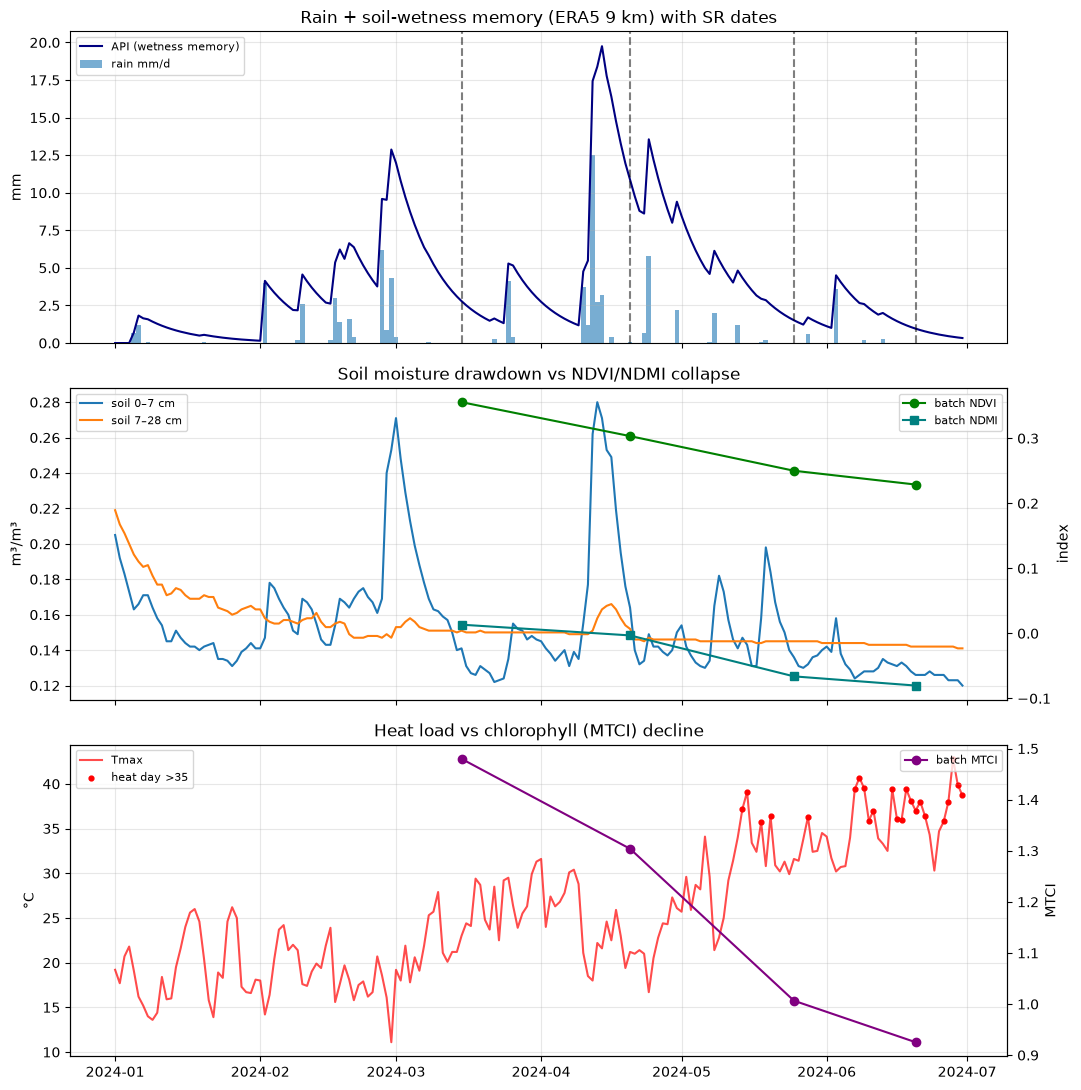

wrote meteo_agri.png


In [5]:
def _s(name): return [float(ts[(ts['date'] == d) & (ts['index'] == name)]['mean'].iloc[0]) for d in DATES]
sr_dates = pd.to_datetime(DATES)
fig, ax = plt.subplots(3, 1, figsize=(11, 11), sharex=True)
a = ax[0]
a.bar(met['date'], met['rain'], width=1, color='tab:blue', alpha=0.6, label='rain mm/d')
a.plot(met['date'], met['api'], color='navy', label='API (wetness memory)')
a.set_ylabel('mm'); a.legend(fontsize=8, loc='upper left'); a.set_title('Rain + soil-wetness memory (ERA5 9 km) with SR dates'); a.grid(alpha=0.3)
for d in sr_dates: a.axvline(d, color='k', ls='--', alpha=0.5)
b = ax[1]
b.plot(met['date'], met['sm07'], label='soil 0–7 cm'); b.plot(met['date'], met['sm28'], label='soil 7–28 cm')
b2 = b.twinx(); b2.plot(sr_dates, _s('ndvi'), 'o-', color='green', label='batch NDVI'); b2.plot(sr_dates, _s('ndmi'), 's-', color='teal', label='batch NDMI')
b.set_ylabel('m³/m³'); b2.set_ylabel('index'); b.legend(fontsize=8, loc='upper left'); b2.legend(fontsize=8, loc='upper right')
b.set_title('Soil moisture drawdown vs NDVI/NDMI collapse'); b.grid(alpha=0.3)
c = ax[2]
c.plot(met['date'], met['tmax'], color='red', alpha=0.7, label='Tmax')
c.scatter(met.loc[met['heat'] == 1, 'date'], met.loc[met['heat'] == 1, 'tmax'], color='red', s=12, label='heat day >35')
c2 = c.twinx(); c2.plot(sr_dates, _s('mtci'), 'o-', color='purple', label='batch MTCI')
c.set_ylabel('°C'); c2.set_ylabel('MTCI'); c.legend(fontsize=8, loc='upper left'); c2.legend(fontsize=8, loc='upper right')
c.set_title('Heat load vs chlorophyll (MTCI) decline'); c.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(BATCH / 'meteo_agri.png', dpi=130)
plt.show()
print('wrote meteo_agri.png')

## 5. Per-crop × meteo table + irrigation flags

crop                   ndviΔ  healthΔ | rain mm heatd    GDD  flag
vegetable/high-chl   -0.259 -0.122 |    45.6    16   1057  heat-hit
cereal-like          -0.153 -0.067 |    45.6    16   1057  rainfed-drydown
mixed/other          -0.183 -0.085 |    45.6    16   1057  heat-hit
orchard/sparse       -0.270 -0.124 |    45.6    16   1057  heat-hit


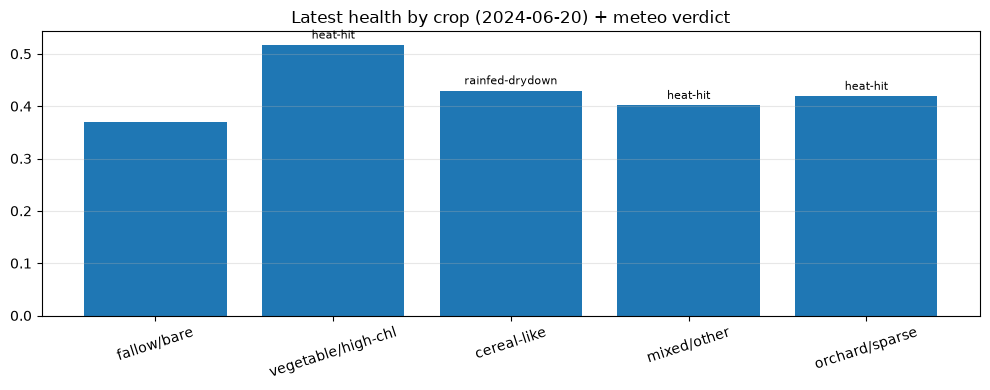

wrote crop_meteo.png | flags: {'vegetable/high-chl': 'heat-hit', 'cereal-like': 'rainfed-drydown', 'mixed/other': 'heat-hit', 'orchard/sparse': 'heat-hit'}


In [6]:
def _met_between(d0, d1):
    w = met[(met['date'] > pd.Timestamp(d0)) & (met['date'] <= pd.Timestamp(d1))]
    return dict(rain=float(w['rain'].sum()), heat=int(w['heat'].sum()), gdd=float(w['gdd'].sum()),
                sm_end=float(w['sm07'].iloc[-1]) if len(w) else float('nan'))
print(f"{'crop':20s} {'ndviΔ':>7s} {'healthΔ':>8s} | {'rain mm':>7s} {'heatd':>5s} {'GDD':>6s}  flag")
flags = {}
for _, r in ch.iterrows():
    if r['crop'] in ('water', 'fallow/bare'): continue
    nd = r[f'ndvi_{DATES[-1]}'] - r[f'ndvi_{DATES[0]}']
    hd = r[f'health_{DATES[-1]}'] - r[f'health_{DATES[0]}']
    w = _met_between(DATES[0], DATES[-1])
    flag = 'IRRIGATED?' if (nd > -0.05 and w['rain'] < 60) else ('heat-hit' if (w['heat'] > 0 and hd < -0.08) else 'rainfed-drydown')
    flags[r['crop']] = flag
    print(f"{r['crop']:20s} {nd:+.3f} {hd:+.3f} | {w['rain']:7.1f} {w['heat']:5d} {w['gdd']:6.0f}  {flag}")
fig, ax = plt.subplots(figsize=(10, 4))
cc = [c for c in ch['crop'] if c != 'water']
ax.bar(cc, [float(ch[ch['crop'] == c][f'health_{DATES[-1]}'].iloc[0]) for c in cc])
ax.set_title(f"Latest health by crop ({DATES[-1]}) + meteo verdict")
ax.tick_params(axis='x', rotation=18); ax.grid(alpha=0.3, axis='y')
hh = [float(ch[ch['crop'] == c][f'health_{DATES[-1]}'].iloc[0]) for c in cc]
for i, c in enumerate(cc): ax.text(i, hh[i] + 0.012, flags.get(c, ''), ha='center', fontsize=8, rotation=0)
fig.tight_layout(); fig.savefig(BATCH / 'crop_meteo.png', dpi=130)
plt.show()
print('wrote crop_meteo.png | flags:', flags)

## 6. Append meteo section to the batch report

In [7]:
s = pd.read_csv(BATCH / 'meteo_summary.csv').iloc[0]
L = ['## Meteo context (ERA5 9 km, Open-Meteo archive)', '']
L.append(f"- Jan–Jun 2024 rain {s['jan_jun_rain_2024_mm']:.0f} mm vs 2015–2023 mean {s['jan_jun_rain_climo_mm']:.0f} mm; "
         f"heat days {int(s['heat_days'])}, longest dry run {int(s['max_dry_run_d'])} d, GDD {s['cum_gdd_jun20']:.0f}, cum. deficit {s['cum_deficit_jun20_mm']:.0f} mm.")
L.append('- NDVI/NDMI fall tracks topsoil-moisture drawdown; MTCI collapse coincides with first heat load — see meteo_agri.png.')
L.append('- Per-crop verdicts (rainfed vs heat-hit vs possibly irrigated): ' + '; '.join(f'{k}={v}' for k, v in flags.items()) + '.')
L.append('- Limits: meteo is 9 km context, not parcel truth; soil moisture is reanalysis-modeled; irrigation flags are hypotheses for field check.')
L.append('- Files: meteo_daily.csv, meteo_climo.csv, meteo_summary.csv, meteo_agri.png, crop_meteo.png')
open(BATCH / 'BATCH_REPORT.md', 'a').write('\n' + '\n'.join(L) + '\n')
print('\n'.join(L))

## Meteo context (ERA5 9 km, Open-Meteo archive)

- Jan–Jun 2024 rain 73 mm vs 2015–2023 mean 116 mm; heat days 23, longest dry run 27 d, GDD 1345, cum. deficit -769 mm.
- NDVI/NDMI fall tracks topsoil-moisture drawdown; MTCI collapse coincides with first heat load — see meteo_agri.png.
- Per-crop verdicts (rainfed vs heat-hit vs possibly irrigated): vegetable/high-chl=heat-hit; cereal-like=rainfed-drydown; mixed/other=heat-hit; orchard/sparse=heat-hit.
- Limits: meteo is 9 km context, not parcel truth; soil moisture is reanalysis-modeled; irrigation flags are hypotheses for field check.
- Files: meteo_daily.csv, meteo_climo.csv, meteo_summary.csv, meteo_agri.png, crop_meteo.png
